In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation & validation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries successfully imported!")

Libraries successfully imported!


In [2]:
import pandas as pd
import os

# Check the environment
if os.path.exists('/kaggle/input'):
    # Kaggle environment
    train_path = '/kaggle/input/competitions/titanic/train.csv'
    test_path = '/kaggle/input/competitions/titanic/test.csv'
else:
    # Local environment
    train_path = 'data/train.csv'
    test_path = 'data/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
print(f"Loaded train shape: {train.shape}")
print(f"Loaded test shape: {test.shape}")

Loaded train shape: (891, 12)
Loaded test shape: (418, 11)


In [3]:
# Print data overview and head
print("--- Train Info ---")
train.info()
print("\n--- Missing Values in Train ---")
print(train.isnull().sum())
print("\n--- Missing Values in Test ---")
print(test.isnull().sum())

display(train.head())

--- Train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Missing Values in Train ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Ca

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


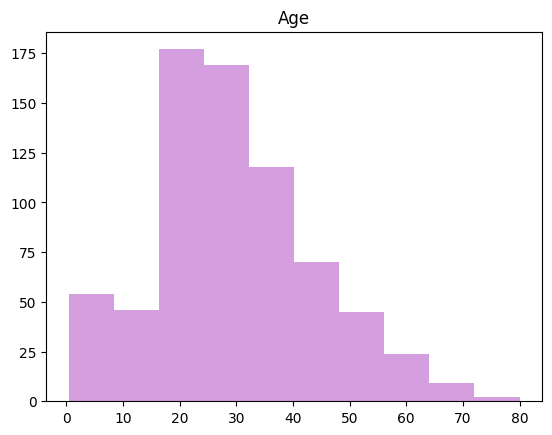

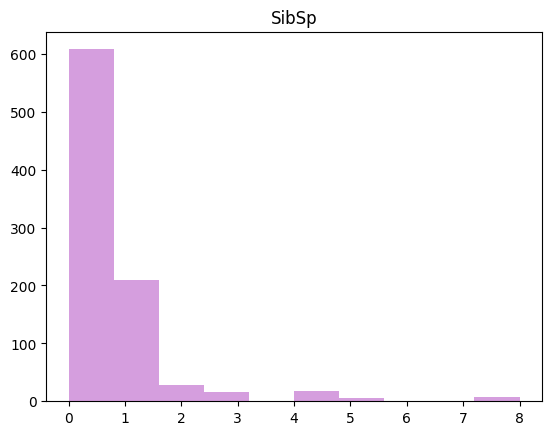

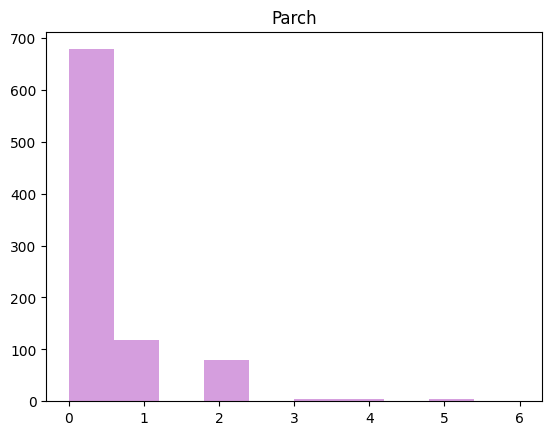

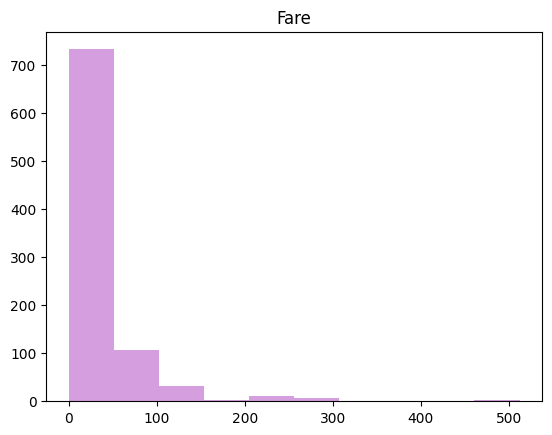

In [4]:
df_num = train[["Age", "SibSp", "Parch", "Fare"]]
df_cat = train[["Survived", "Sex", "Cabin", "Embarked", "Ticket"]]
for i in df_num.columns:
    plt.hist(df_num[i], color='#D59EDE')
    plt.title(i)
    plt.show()

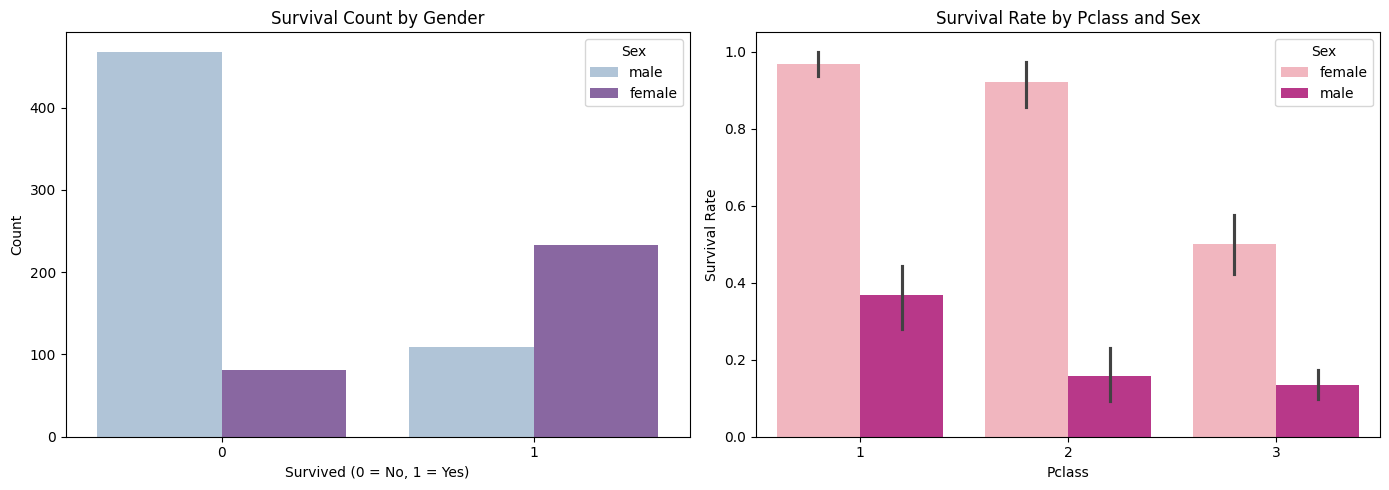

In [5]:
# Visualize survival distributions by gender and passenger class
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=train, x='Survived', hue='Sex', palette='BuPu')
plt.title('Survival Count by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.barplot(data=train, x='Pclass', y='Survived', hue='Sex', palette='RdPu')
plt.title('Survival Rate by Pclass and Sex')
plt.ylabel('Survival Rate')

plt.tight_layout()
plt.show()

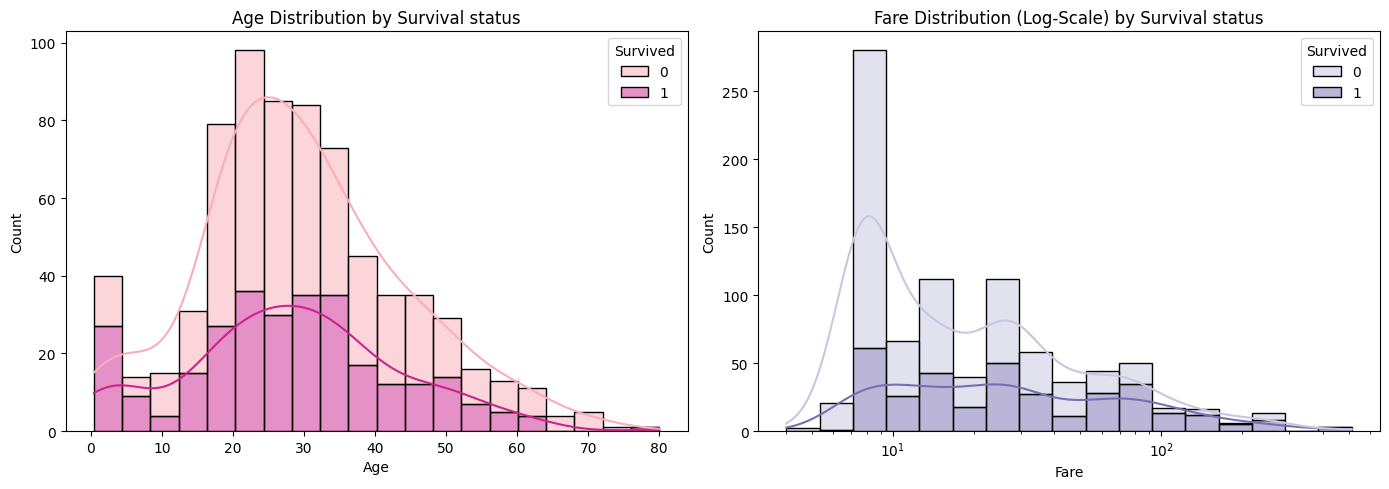

In [6]:
# Visualize Age and Fare distributions by Survival state
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=train, x='Age', hue='Survived', kde=True, multiple='stack', palette='RdPu')
plt.title('Age Distribution by Survival status')

plt.subplot(1, 2, 2)
sns.histplot(data=train[train['Fare'] > 0], x='Fare', hue='Survived', kde=True, multiple='stack', palette='Purples', log_scale=True)
plt.title('Fare Distribution (Log-Scale) by Survival status')

plt.tight_layout()
plt.show()

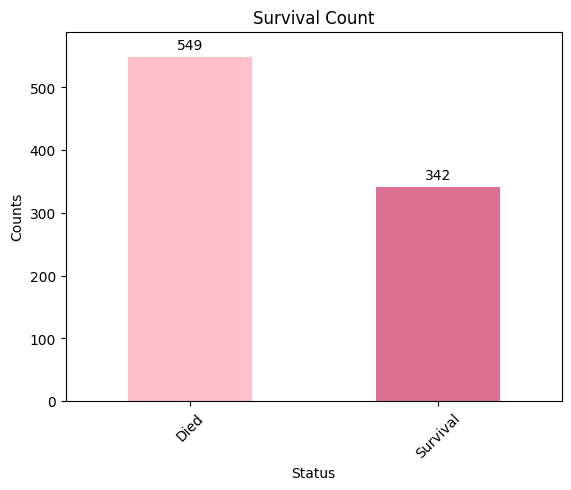

In [7]:
import matplotlib.pyplot as plt

survival_count = train['Survived'].value_counts()

survival_count.plot(kind = 'bar', color = ['Pink', 'PaleVioletRed'])

plt.title('Survival Count')

plt.xticks(ticks = [0,1], labels = ['Died','Survival'], rotation = 45)

plt.xlabel('Status')

plt.ylabel('Counts')

plt.ylim(0, max(survival_count) + 40)

ax = plt.gca()

for container in ax.containers:
    ax.bar_label(container, padding = 3)

plt.show()

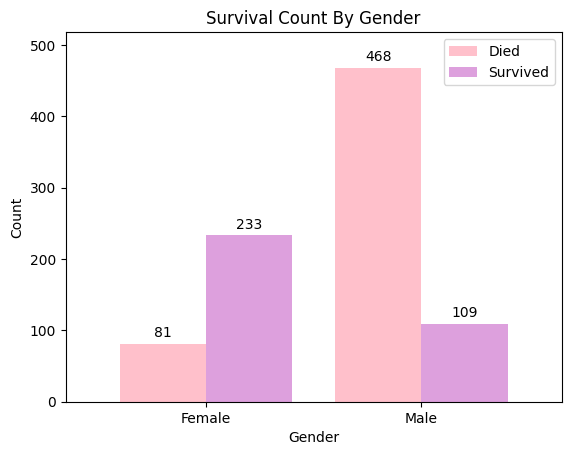

In [8]:
gender_survival = train.groupby(['Sex', 'Survived']).size().unstack()

ax = gender_survival.plot(kind='bar', color=['Pink', 'Plum'], width=0.8)

plt.title('Survival Count By Gender')

plt.xticks(ticks=[0, 1], labels=['Female', 'Male'], rotation=0)
plt.xlabel('Gender')
plt.ylabel('Count')

plt.legend(labels=['Died', 'Survived'])

plt.ylim(0, gender_survival.values.max() + 50)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

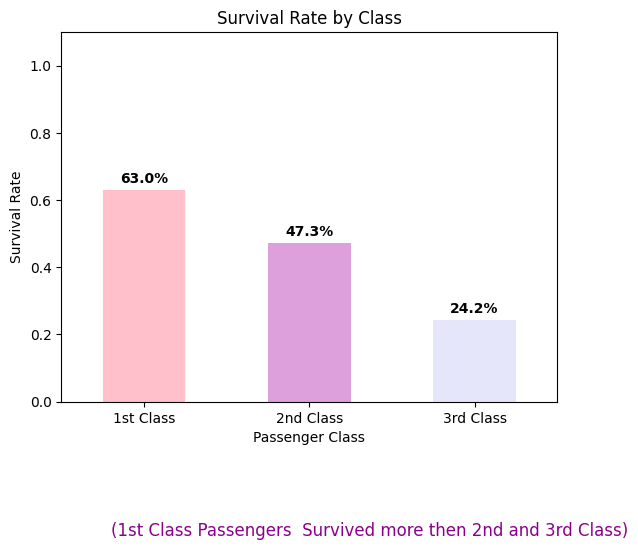

In [9]:
pclass_survival = train.groupby('Pclass')['Survived'].mean()

ax = pclass_survival.plot(kind='bar', color=['Pink', 'Plum', 'Lavender'])

plt.title('Survival Rate by Class')

plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'], rotation=0)

plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.ylim(0, 1.1)
plt.text(-0.2, -0.4, "(1st Class Passengers  Survived more then 2nd and 3rd Class)", fontsize=12, color='DarkMagenta')
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt=lambda x: f'{x*100:.1f}%', fontweight='bold')

plt.show()

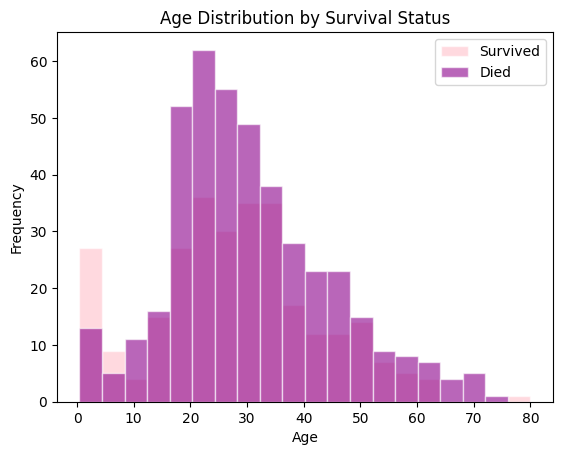

In [10]:
age_data = train['Age'].dropna()

bins = np.linspace(age_data.min(), age_data.max(), 21)

train[train['Survived']==1]['Age'].plot(kind='hist',bins = bins,color = 'Pink',alpha = 0.6, label = 'Survived', edgecolor = 'white')

train[train['Survived'] == 0]['Age'].plot(kind='hist',bins = bins, color = 'DarkMagenta', alpha = 0.6, label = 'Died', edgecolor = 'white')

plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.legend()

plt.show()

In [11]:
# 1. Impute missing values for 'Age' based on the median of Pclass and Sex groups
train['Age'] = train.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
test['Age'] = test.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# 2. Impute missing values for 'Embarked' in train dataset with the most frequent value (mode)
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# 3. Impute missing values for 'Fare' in test dataset with the median Fare of the train dataset
test['Fare'] = test['Fare'].fillna(train['Fare'].median())

# 4. Cabin has too many missing values, fill them with a placeholder 'U' for Unknown
train['Cabin'] = train['Cabin'].fillna('U')
test['Cabin'] = test['Cabin'].fillna('U')

# Verify missing values are handled
print("--- Missing Values in Train after Preprocessing ---")
print(train.isnull().sum())
print("\n--- Missing Values in Test after Preprocessing ---")
print(test.isnull().sum())

--- Missing Values in Train after Preprocessing ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

--- Missing Values in Test after Preprocessing ---
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [12]:
# 1. Extract titles from name
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Group rare titles
title_mapping = {
    "Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, 
    "Dr": 5, "Rev": 5, "Col": 5, "Major": 5, "Mlle": 2, 
    "Mme": 3, "Don": 5, "Lady": 5, "Countess": 5, "Jonkheer": 5, 
    "Sir": 5, "Capt": 5, "Ms": 2, "Dona": 5
}
train['Title'] = train['Title'].map(title_mapping).fillna(5)
test['Title'] = test['Title'].map(title_mapping).fillna(5)

# 2. Family Size and IsAlone
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

# 3. Map Categorical features
# Sex: male -> 0, female -> 1
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

# Embarked: S -> 0, C -> 1, Q -> 2
train['Embarked'] = train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. Feature Selection: Drop columns that won't be used in the model
features_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_features = train.drop(columns=features_to_drop + ['Survived'])
train_target = train['Survived']
test_features = test.drop(columns=features_to_drop)

print("Features selected for training:")
print(train_features.head())



Features selected for training:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  FamilySize  \
0       3    0  22.0      1      0   7.2500         0      1           2   
1       1    1  38.0      1      0  71.2833         1      3           2   
2       3    1  26.0      0      0   7.9250         0      2           1   
3       1    1  35.0      1      0  53.1000         0      3           2   
4       3    0  35.0      0      0   8.0500         0      1           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost
import lightgbm
import pandas as pd
import numpy as np

# Define models
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVC': make_pipeline(StandardScaler(), SVC(random_state=42)),
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier()),
    'XGBoost': xgboost.XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lightgbm.LGBMClassifier(random_state=42, verbosity=-1)
}

# Evaluate models using 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("--- 5-Fold Cross-Validation Accuracy ---")
for name, model in models.items():
    scores = cross_val_score(model, train_features, train_target, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}: Mean Accuracy = {scores.mean():.4f} (Std = {scores.std():.4f})")

# Perform GridSearch hyperparameter tuning on top candidates: Random Forest and Gradient Boosting
print("\n--- Hyperparameter Tuning ---")

# RF Tuning
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=rf_param_grid, cv=cv, scoring='accuracy')
rf_grid.fit(train_features, train_target)
print(f"Best Random Forest CV Accuracy: {rf_grid.best_score_:.4f}")
print(f"Best parameters: {rf_grid.best_params_}")

# GB Tuning
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid=gb_param_grid, cv=cv, scoring='accuracy')
gb_grid.fit(train_features, train_target)
print(f"Best Gradient Boosting CV Accuracy: {gb_grid.best_score_:.4f}")
print(f"Best parameters: {gb_grid.best_params_}")

# Select best estimator
if rf_grid.best_score_ >= gb_grid.best_score_:
    best_model = rf_grid.best_estimator_
    best_name = "Random Forest (Tuned)"
    best_score = rf_grid.best_score_
else:
    best_model = gb_grid.best_estimator_
    best_name = "Gradient Boosting (Tuned)"
    best_score = gb_grid.best_score_

print(f"\nSelected Best Model: {best_name} with CV score {best_score:.4f}")

--- 5-Fold Cross-Validation Accuracy ---
Logistic Regression: Mean Accuracy = 0.8148 (Std = 0.0176)
Random Forest: Mean Accuracy = 0.8204 (Std = 0.0099)
Gradient Boosting: Mean Accuracy = 0.8339 (Std = 0.0142)
SVC: Mean Accuracy = 0.8294 (Std = 0.0136)
KNN: Mean Accuracy = 0.8047 (Std = 0.0174)
XGBoost: Mean Accuracy = 0.8238 (Std = 0.0226)
LightGBM: Mean Accuracy = 0.8350 (Std = 0.0230)

--- Hyperparameter Tuning ---
Best Random Forest CV Accuracy: 0.8406
Best parameters: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Gradient Boosting CV Accuracy: 0.8485
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50}

Selected Best Model: Gradient Boosting (Tuned) with CV score 0.8485


In [14]:
import os

# Train best model on full dataset
best_model.fit(train_features, train_target)

# Predict on test set
predictions = best_model.predict(test_features)

# Create submission df
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})

# Save to csv
submission_path = 'submissions/submission.csv'
os.makedirs(os.path.dirname(submission_path), exist_ok=True)
submission.to_csv(submission_path, index=False)
print(f"Submission successfully saved to {submission_path}")
print(submission.head())

Submission successfully saved to submissions/submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
